# Day 17 — RSI 指标（相对强弱指数）

**目标**：理解RSI的计算逻辑，知道超买超卖是什么意思

- 🌅 上午：RSI公式推导 + 手算14日RSI
- ☀️ 下午：股价+RSI双面板图 + 超买超卖区域标注
- 🌙 晚上：3只股票历史RSI信号验证

In [1]:
# ===== 基础设置 =====
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 环境就绪')

✅ 环境就绪


## 🌅 上午：RSI是什么？

RSI（Relative Strength Index，相对强弱指数）由 Welles Wilder 在1978年提出。

**一句话**：衡量最近一段时间「涨的力量」和「跌的力量」谁更强。

### 公式推导

**第一步：每天涨了多少，跌了多少？**

$$\text{涨幅} = \max(P_{today} - P_{yesterday},\ 0)$$
$$\text{跌幅} = \max(P_{yesterday} - P_{today},\ 0)$$

**第二步：算14天平均涨幅和平均跌幅（Wilder平滑）**

第一天：简单平均
$$\text{AvgGain}_{14} = \frac{G_1 + G_2 + ... + G_{14}}{14}$$

之后每一天：递推平滑
$$\text{AvgGain}_{today} = \frac{\text{AvgGain}_{yesterday} \times 13 + G_{today}}{14}$$

**第三步：算RS（相对强弱）**

$$RS = \frac{\text{AvgGain}}{\text{AvgLoss}}$$

**第四步：RSI = 把RS映射到0~100**

$$RSI = 100 - \frac{100}{1 + RS}$$

### 直觉理解

- 如果14天全涨（AvgLoss=0）→ RS=∞ → RSI=100
- 如果14天全跌（AvgGain=0）→ RS=0 → RSI=0
- 涨跌各半 → RS≈1 → RSI≈50

**经验法则**：
- RSI > 70 → 超买（涨太多了，可能要回调）
- RSI < 30 → 超卖（跌太多了，可能要反弹）

> RSI和MACD一样，用的还是EMA思想——Wilder平滑就是EMA(N=14, k=1/14)。Day15的EMA你今天已经第三次遇到了。

In [2]:
# 加载茅台数据
df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()

print(f'数据: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')
df[['收盘']].tail(5)

数据: 250 行, 2025-07-01 ~ 2026-07-10


,收盘
日期,
2026-07-06,1206.91
2026-07-07,1188.80
2026-07-08,1199.30
2026-07-09,1182.19
2026-07-10,1204.98


## ☀️ 下午：手算RSI

和Day15手算EMA一样——拆开每一步，验证和Pandas算出来的一致。

In [3]:
# ===== 手算14日RSI全过程 =====

N = 14

# 第一步：每天的价格变化
df['涨跌'] = df['收盘'].diff()  # 今天 - 昨天

# 第二步：拆成涨幅和跌幅（都是正数）
df['涨幅'] = df['涨跌'].clip(lower=0)    # 涨了就是正，没涨就是0
df['跌幅'] = (-df['涨跌']).clip(lower=0)  # 跌了就是正，没跌就是0

# 第三步：Wilder平滑（递推公式）
# 前14天用简单平均做初始值
first_gains = df['涨幅'].iloc[1:N+1]   # 跳过第1天（没有涨跌）
first_losses = df['跌幅'].iloc[1:N+1]

avg_gain = first_gains.mean()
avg_loss = first_losses.mean()

rsi_values = [np.nan] * N  # 前14天不够算

# 第15天开始递推
for i in range(N, len(df)):
    avg_gain = (avg_gain * (N - 1) + df['涨幅'].iloc[i]) / N
    avg_loss = (avg_loss * (N - 1) + df['跌幅'].iloc[i]) / N
    
    if avg_loss == 0:
        rsi = 100.0
    else:
        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
    rsi_values.append(rsi)

df['RSI_手算'] = rsi_values

# 显示递推过程（前20天）
print('手算RSI递推过程（前20天）：')
display(df[['收盘', '涨跌', '涨幅', '跌幅', 'RSI_手算']].head(20).round(2))

print(f'\n最新RSI(手算) = {df["RSI_手算"].iloc[-1]:.1f}')

手算RSI递推过程（前20天）：


,收盘,涨跌,涨幅,跌幅,RSI_手算
日期,,,,,
2025-07-01,1353.12,NaN,NaN,NaN,NaN
2025-07-02,1357.62,4.50,4.50,0.00,NaN
2025-07-03,1363.62,6.00,6.00,0.00,NaN
2025-07-04,1370.24,6.62,6.62,0.00,NaN
2025-07-07,1358.72,-11.52,0.00,11.52,NaN
2025-07-08,1364.13,5.41,5.41,0.00,NaN
2025-07-09,1366.90,2.77,2.77,0.00,NaN
2025-07-10,1374.52,7.62,7.62,0.00,NaN
2025-07-11,1375.02,0.50,0.50,0.00,NaN



最新RSI(手算) = 46.8


In [4]:
# ===== 验证：手算 vs Pandas ewm =====

# Wilder平滑 = ewm(alpha=1/N)，和手算递推等价
def rsi_wilder(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI_ewm'] = rsi_wilder(df['收盘'], N)

# 对比最后20天
compare = df[['收盘', 'RSI_手算', 'RSI_ewm']].dropna().tail(20).round(2)
compare['差异'] = (compare['RSI_手算'] - compare['RSI_ewm']).abs()
display(compare)

max_diff = compare['差异'].max()
print(f'\n最大差异: {max_diff:.6f}')
print('→ 两种算法一致 ✅' if max_diff < 0.01 else '→ 有差异，需要检查 ⚠️')

,收盘,RSI_手算,RSI_ewm,差异
日期,,,,
2026-06-12,1263.89,44.58,44.58,0.0
2026-06-15,1243.08,39.83,39.83,0.0
2026-06-16,1227.65,36.71,36.71,0.0
2026-06-17,1211.98,33.81,33.81,0.0
2026-06-18,1186.98,29.77,29.77,0.0
2026-06-22,1213.39,38.17,38.17,0.0
2026-06-23,1194.43,34.94,34.94,0.0
2026-06-24,1179.66,32.62,32.62,0.0
2026-06-25,1184.08,34.03,34.03,0.0



最大差异: 0.000000
→ 两种算法一致 ✅


### RSI双面板图：股价 + RSI + 超买超卖线

findfont: Failed to find font weight normal, now using 300.


findfont: Failed to find font weight normal, now using 300.


findfont: Failed to find font weight bold, now using 600.


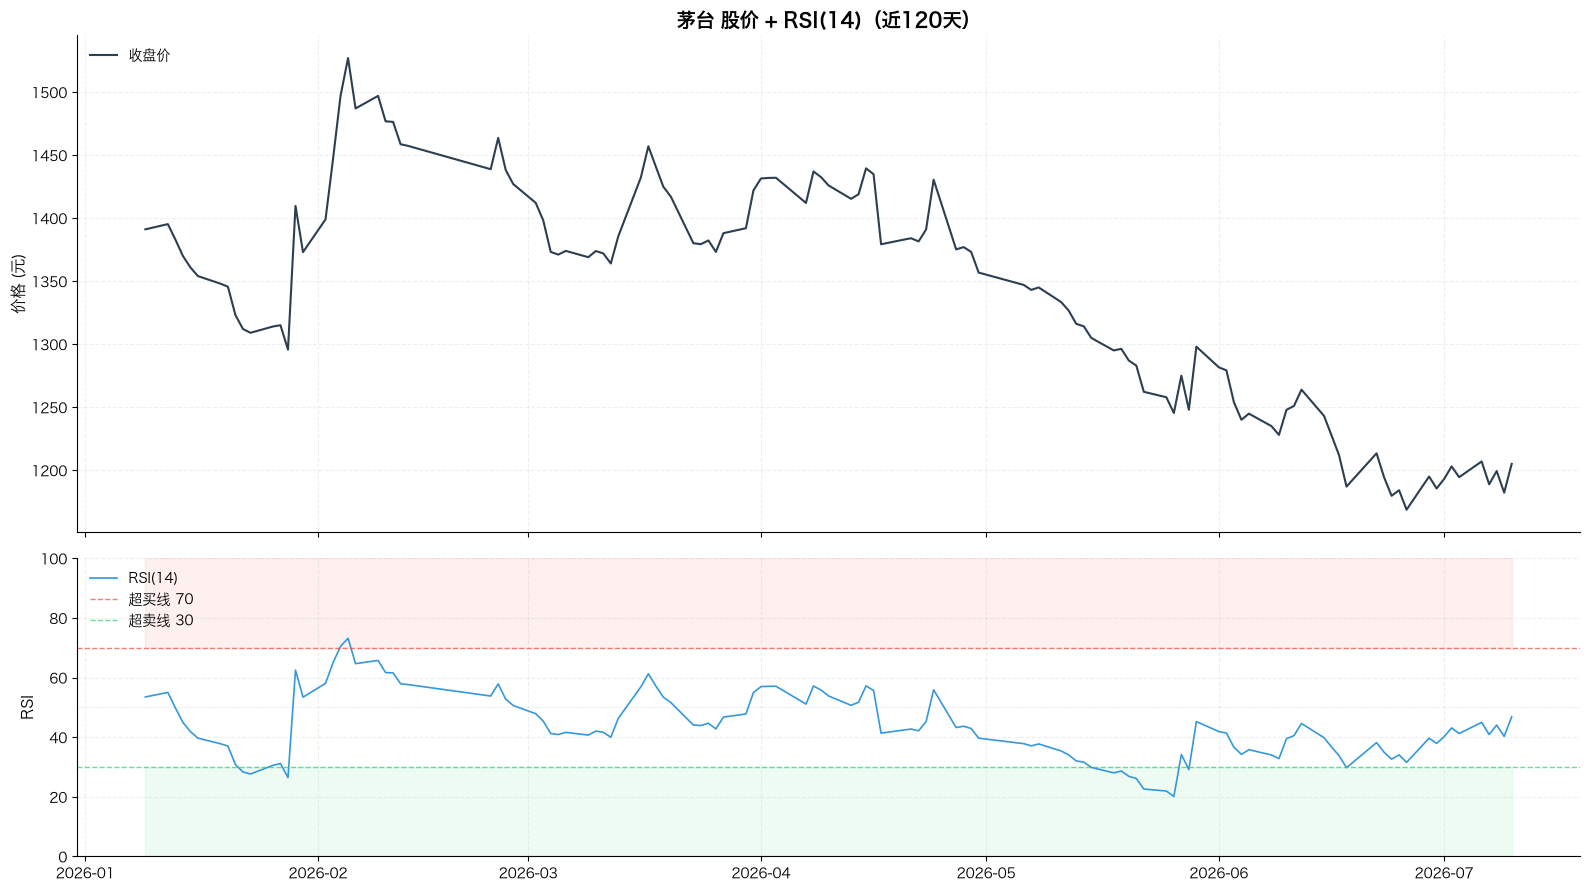

近120天: RSI>70（超买）2天 | RSI<30（超卖）13天


In [5]:
# ===== 股价 + RSI 双面板图 =====

d = df.iloc[-120:].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9),
                                gridspec_kw={'height_ratios': [2.5, 1.5]}, sharex=True)

# 上：收盘价
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax1.set_ylabel('价格 (元)', fontsize=11)
ax1.set_title('茅台 股价 + RSI(14)（近120天）', fontsize=14, fontweight='bold')
ax1.legend(frameon=False, fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.2, ls='--')

# 下：RSI
ax2.plot(d.index, d['RSI_手算'], color='#3498db', lw=1.2, label='RSI(14)')
ax2.axhline(70, color='#e74c3c', lw=1.0, ls='--', alpha=0.7, label='超买线 70')
ax2.axhline(30, color='#2ecc71', lw=1.0, ls='--', alpha=0.7, label='超卖线 30')
ax2.axhline(50, color='gray', lw=0.5, ls=':', alpha=0.4)

# 填充超买/超卖区域
ax2.fill_between(d.index, 70, 100, alpha=0.08, color='#e74c3c')
ax2.fill_between(d.index, 0, 30, alpha=0.08, color='#2ecc71')

ax2.set_ylabel('RSI', fontsize=11)
ax2.set_ylim(0, 100)
ax2.legend(frameon=False, fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.2, ls='--')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 统计超买超卖天数
overbought = (d['RSI_手算'] > 70).sum()
oversold = (d['RSI_手算'] < 30).sum()
print(f'近120天: RSI>70（超买）{overbought}天 | RSI<30（超卖）{oversold}天')

### RSI超买/超卖信号——验证它到底灵不灵

信号定义：
- **超买信号**：RSI从下方突破70（涨太多了，看跌）
- **超卖信号**：RSI从上方跌破30（跌太多了，看涨）

⚠️ 注意：RSI超买不等于马上跌，超卖不等于马上涨。RSI可以长时间待在超买/超卖区。

In [6]:
# ===== RSI超买/超卖信号检测 =====

# 超买信号：RSI上穿70
df['超买信号'] = (df['RSI_手算'] > 70) & (df['RSI_手算'].shift(1) <= 70)
# 超卖信号：RSI下穿30
df['超卖信号'] = (df['RSI_手算'] < 30) & (df['RSI_手算'].shift(1) >= 30)

overbought_dates = df[df['超买信号']].index
oversold_dates = df[df['超卖信号']].index

print(f'茅台近一年: 超买信号(RSI上穿70) {len(overbought_dates)} 次')
print(f'超买日期: {[str(d.date()) for d in overbought_dates]}')
print(f'\n茅台近一年: 超卖信号(RSI下穿30) {len(oversold_dates)} 次')
print(f'超卖日期: {[str(d.date()) for d in oversold_dates]}')

茅台近一年: 超买信号(RSI上穿70) 1 次
超买日期: ['2026-02-04']

茅台近一年: 超卖信号(RSI下穿30) 5 次
超卖日期: ['2026-01-22', '2026-01-28', '2026-05-15', '2026-05-28', '2026-06-18']


In [7]:
# ===== RSI信号回测 =====

def check_signal(df, signal_col, hold_days=5):
    signal_dates = df[df[signal_col]].index
    results = []
    for date in signal_dates:
        pos = df.index.get_loc(date)
        if pos + hold_days >= len(df):
            continue
        buy_price = df['收盘'].iloc[pos]
        sell_price = df['收盘'].iloc[pos + hold_days]
        ret = (sell_price / buy_price - 1) * 100
        results.append({'信号日': date.strftime('%Y-%m-%d'),
                        '买入价': buy_price,
                        f'{hold_days}天后卖出价': sell_price,
                        '收益率(%)': ret})
    return pd.DataFrame(results)

print('=' * 60)
print('超买信号(RSI>70)出现后5天——超买=涨太多应该回调下跌')
print('=' * 60)
ob_result = check_signal(df, '超买信号', hold_days=5)
if len(ob_result) > 0:
    print(ob_result.round(2).to_string(index=False))
    down = sum(ob_result['收益率(%)'] < 0)
    total = len(ob_result)
    print(f'\n📊 超买后5天下跌概率: {down}/{total} = {down/total*100:.0f}% | 平均收益 {ob_result["收益率(%)"].mean():.2f}%')

print()
print('=' * 60)
print('超卖信号(RSI<30)出现后5天——超卖=跌太多应该反弹上涨')
print('=' * 60)
os_result = check_signal(df, '超卖信号', hold_days=5)
if len(os_result) > 0:
    print(os_result.round(2).to_string(index=False))
    up = sum(os_result['收益率(%)'] > 0)
    total = len(os_result)
    print(f'\n📊 超卖后5天上涨概率: {up}/{total} = {up/total*100:.0f}% | 平均收益 {os_result["收益率(%)"].mean():.2f}%')

超买信号(RSI>70)出现后5天——超买=涨太多应该回调下跌
       信号日     买入价  5天后卖出价  收益率(%)
2026-02-04 1496.98 1476.31   -1.38

📊 超买后5天下跌概率: 1/1 = 100% | 平均收益 -1.38%

超卖信号(RSI<30)出现后5天——超卖=跌太多应该反弹上涨
       信号日     买入价  5天后卖出价  收益率(%)
2026-01-22 1312.04 1409.70    7.44
2026-01-28 1295.67 1496.98   15.54
2026-05-15 1304.93 1262.18   -3.28
2026-05-28 1247.96 1239.98   -0.64
2026-06-18 1186.98 1168.63   -1.55

📊 超卖后5天上涨概率: 2/5 = 40% | 平均收益 3.50%


findfont: Failed to find font weight bold, now using 600.


/var/folders/ch/bmkphb0d7yx8ytft5nsv6gl80000gn/T/ipykernel_32698/3646162875.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Hiragino Sans GB.
  plt.tight_layout()
/Users/macbookpro/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


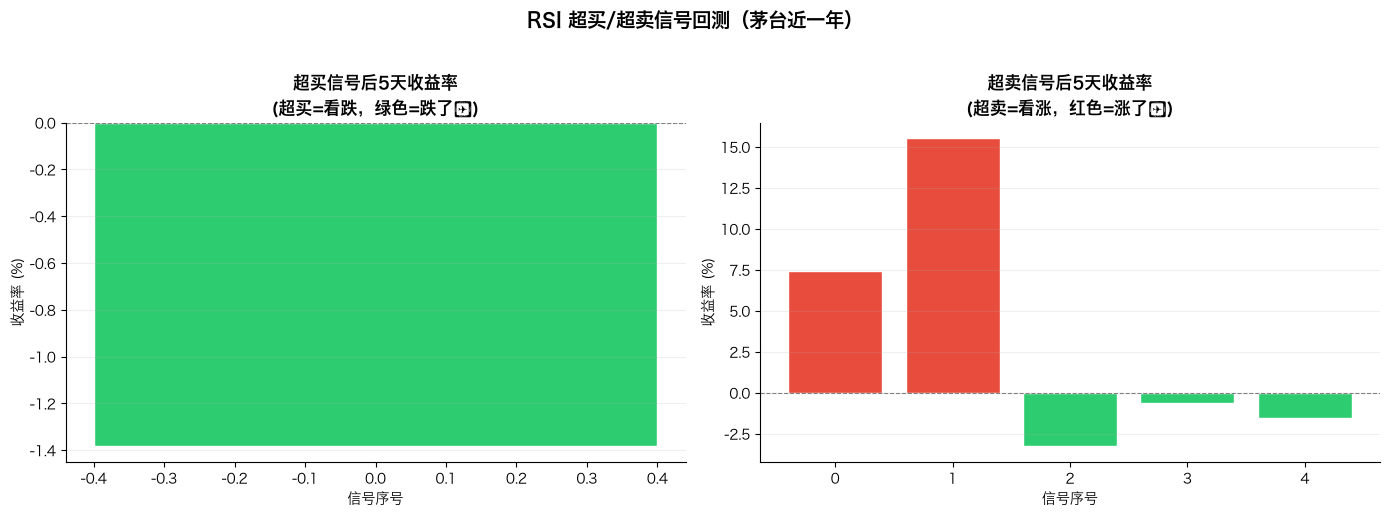

In [8]:
# ===== 可视化回测结果 =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if len(ob_result) > 0:
    colors = ['#2ecc71' if r < 0 else '#e74c3c' for r in ob_result['收益率(%)']]
    ax1.bar(range(len(ob_result)), ob_result['收益率(%)'], color=colors, edgecolor='white')
    ax1.axhline(0, color='gray', lw=0.8, ls='--')
    ax1.set_title('超买信号后5天收益率\n(超买=看跌，绿色=跌了)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('收益率 (%)')
    ax1.set_xlabel('信号序号')

if len(os_result) > 0:
    colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in os_result['收益率(%)']]
    ax2.bar(range(len(os_result)), os_result['收益率(%)'], color=colors, edgecolor='white')
    ax2.axhline(0, color='gray', lw=0.8, ls='--')
    ax2.set_title('超卖信号后5天收益率\n(超卖=看涨，红色=涨了)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('收益率 (%)')
    ax2.set_xlabel('信号序号')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('RSI 超买/超卖信号回测（茅台近一年）', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🌙 晚上：3只股票RSI信号实战

用恒瑞医药、比亚迪、招商银行验证——茅台一个样本不够。

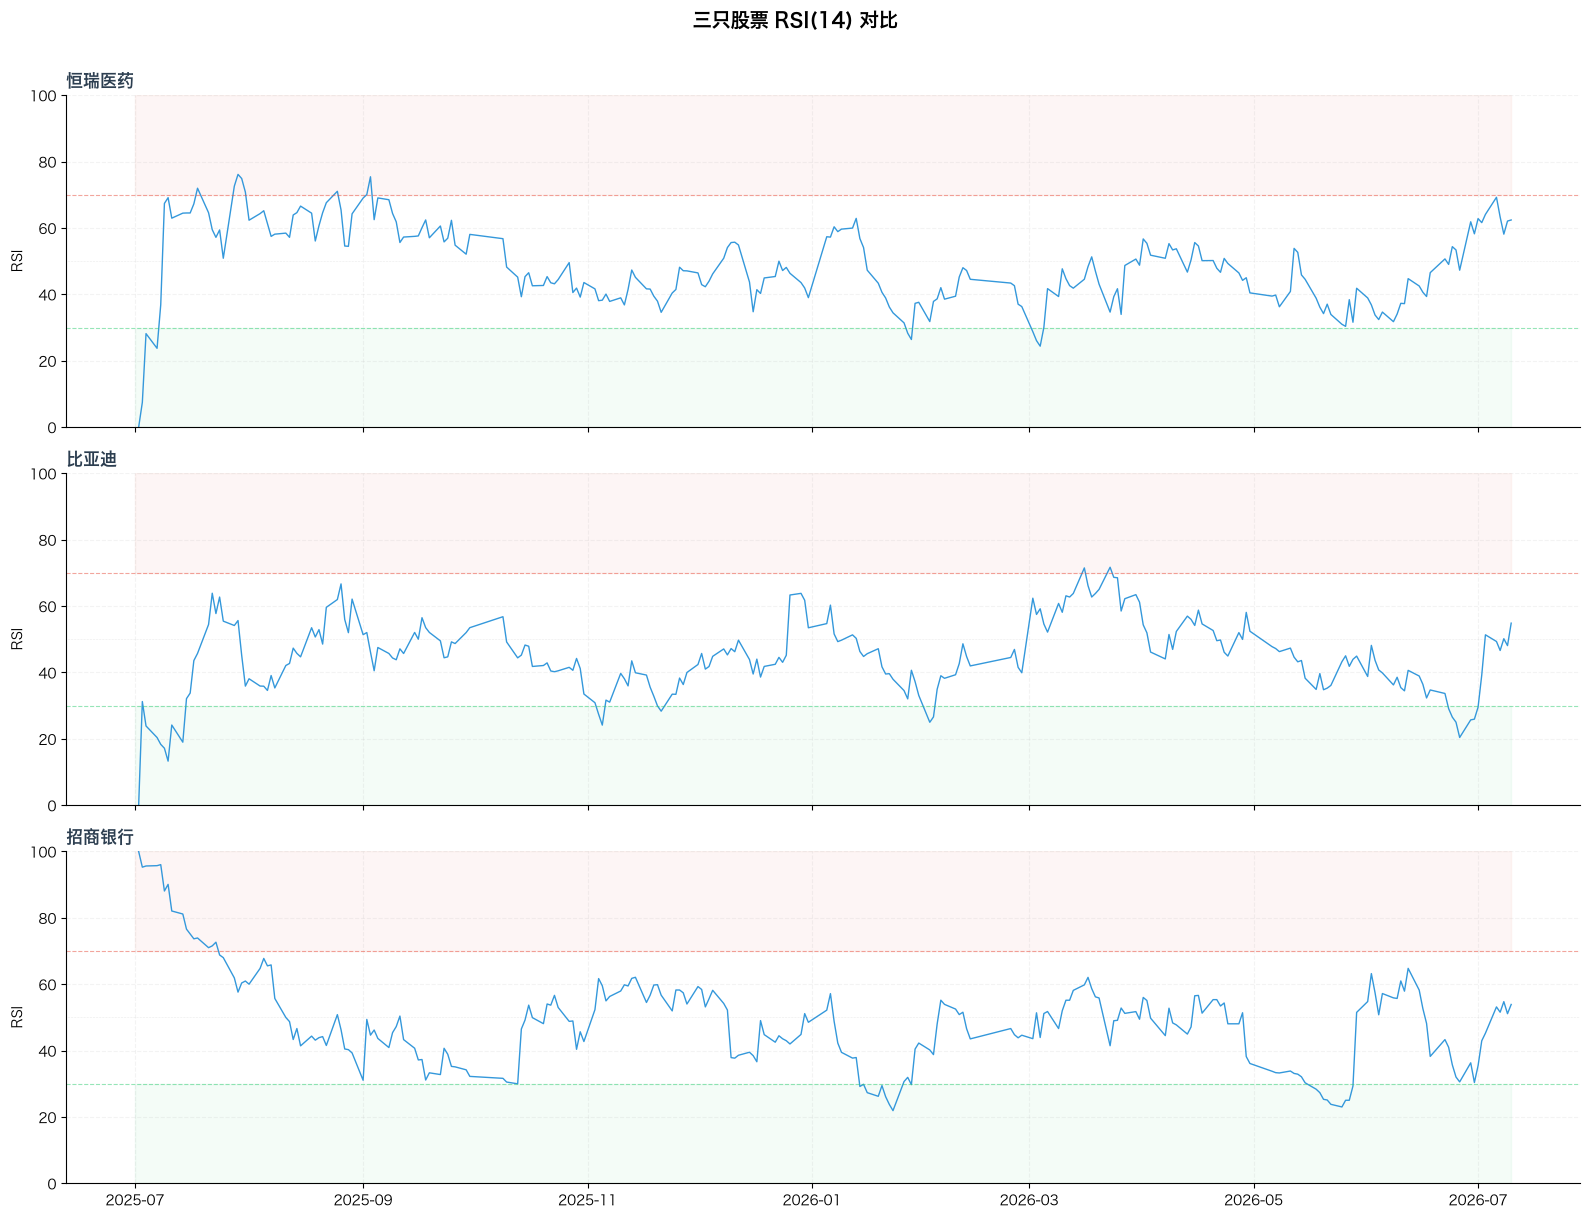

In [9]:
# ===== 多股RSI分析 =====

stocks = {
    '恒瑞医药': '../data/恒瑞医药.csv',
    '比亚迪': '../data/比亚迪.csv',
    '招商银行': '../data/招商银行.csv',
}

def analyze_rsi(filepath, name, period=14):
    d = pd.read_csv(filepath)
    d['日期'] = pd.to_datetime(d['日期'])
    d = d.set_index('日期').sort_index()
    delta = d['收盘'].diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    d['RSI'] = 100 - (100 / (1 + rs))
    d['超买'] = (d['RSI'] > 70) & (d['RSI'].shift(1) <= 70)
    d['超卖'] = (d['RSI'] < 30) & (d['RSI'].shift(1) >= 30)
    return d

results = {}
for name, path in stocks.items():
    results[name] = analyze_rsi(path, name)

# 画三股RSI对比
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, d) in zip(axes, results.items()):
    ax.plot(d.index, d['RSI'], color='#3498db', lw=1.0)
    ax.axhline(70, color='#e74c3c', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(30, color='#2ecc71', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(50, color='gray', lw=0.4, ls=':', alpha=0.3)
    ax.fill_between(d.index, 70, 100, alpha=0.05, color='#e74c3c')
    ax.fill_between(d.index, 0, 30, alpha=0.05, color='#2ecc71')
    ax.set_ylim(0, 100)
    ax.set_ylabel('RSI', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold', loc='left', color='#2c3e50')
    ax.grid(True, alpha=0.15, ls='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('三只股票 RSI(14) 对比', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ===== 统计每只股的RSI信号 =====

print('=' * 70)
print(f'{"股票":<8} {"超买次数":<8} {"超卖次数":<8} {"RSI均值":<8} {"RSI最高":<8} {"RSI最低":<8}')
print('=' * 70)

for name, d in results.items():
    ob = d['超买'].sum()
    os = d['超卖'].sum()
    print(f'{name:<8} {ob:<8} {os:<8} {d["RSI"].mean():<8.1f} {d["RSI"].max():<8.1f} {d["RSI"].min():<8.1f}')

print()
print('最近一次信号:')
for name, d in results.items():
    ob_dates = d[d['超买']].index
    os_dates = d[d['超卖']].index
    if len(ob_dates) > 0:
        print(f'  {name} 超买: {ob_dates[-1].date()} RSI={d.loc[ob_dates[-1], "RSI"]:.1f}')
    if len(os_dates) > 0:
        print(f'  {name} 超卖: {os_dates[-1].date()} RSI={d.loc[os_dates[-1], "RSI"]:.1f}')

股票       超买次数     超卖次数     RSI均值    RSI最高    RSI最低   
恒瑞医药     4        2        48.5     76.1     0.0     
比亚迪      2        5        44.8     71.7     0.0     
招商银行     0        3        48.9     100.0    21.9    

最近一次信号:
  恒瑞医药 超买: 2025-09-02 RSI=70.1
  恒瑞医药 超卖: 2026-03-02 RSI=28.8
  比亚迪 超买: 2026-03-23 RSI=71.7
  比亚迪 超卖: 2026-06-23 RSI=29.1
  招商银行 超卖: 2026-05-18 RSI=28.4


## 📝 RSI vs MACD vs MA——三个指标放在一起看

| 指标 | 衡量什么 | 信号 | 问题 |
|------|---------|------|------|
| MA | 价格趋势 | 金叉/死叉 | 最滞后 |
| MACD | 趋势+动能 | 金叉/死叉+柱变化 | 比MA快，但仍滞后 |
| RSI | 超买超卖程度 | >70 / <30 | 单边行情失效（涨的时候一直在超买区） |

**核心认知**：没有哪个单一指标能稳定赚钱。三个都指向同一方向时，概率才高一点。

## 📝 今天的发现

运行完上面的分析后，回答这三个问题（写进 `day17/学习笔记.txt`）：

1. RSI超买后一定会跌吗？茅台超买信号后下跌概率是多少？
2. 三只股票中谁的RSI波动最大？谁最常进入超买/超卖区？
3. RSI和MACD有什么本质区别？什么时候用RSI、什么时候用MACD？